# Deep RELDEC (z=2) Resume and Monitoring Notebook

This notebook restarts an interrupted Deep RELDEC run and keeps progress visible cell-by-cell.

Default behavior:
- Resume from the latest Deep RELDEC z=2 checkpoint if it exists
- Continue training from that point to a larger episode target
- Write logs and checkpoints under the canonical active run directory
- Provide status, log-tail, metrics plots, and validation summary cells

## 1) Environment and Run Configuration

In [44]:
from pathlib import Path
import os
import json
import time
import subprocess

# Tunables
RUN_ID = "deep_z2_resume_live"
CODE = "wran"
POLICY_TYPE = "deep_z2"
DEVICE = "cpu"  # change to "cuda" if available

# Optional method toggle
INCLUDE_DEEP_Z1 = True

# If True, always start a new training run in RUN_ID checkpoint dir.
# If False, resume from checkpoint_latest.npz in that RUN_ID dir when available.
FORCE_FRESH_RESTART = True

# Resume/restart target for deep z2
TARGET_TOTAL_EPISODES = 120
EPISODES_PER_SNR = 20  # 6 SNR points * 20 = 120 total episodes

# Deep z1 training policy (full run now, resume-safe)
Z1_RUN_ID = "deep_z1_resume_live"
Z1_POLICY_TYPE = "deep_z1"
Z1_FORCE_FRESH_RESTART = False
Z1_TARGET_TOTAL_EPISODES = 120
Z1_EPISODES_PER_SNR = 20

L_MAX = 20
CHECKPOINT_EVERY = 10
LOG_EVERY = 5
SEED = 7

TRAIN_SNR = [1.0, 2.0, 3.0, 4.0, 5.0, 5.5]
EVAL_SNR = [2.0, 2.5, 3.0]
TARGET_FRAME_ERRORS = 60
MAX_FRAMES = 3000

# DQN settings
DQN_HIDDEN_DIM = 128
DQN_LR = 1e-3
DQN_REPLAY_CAPACITY = 20000
DQN_REPLAY_WARMUP = 1000
DQN_BATCH_SIZE = 128
DQN_TARGET_SYNC = 200
DQN_TRAIN_EVERY = 1
DQN_EPS_START = 0.6
DQN_EPS_END = 0.05
DQN_EPS_DECAY = 10000

MIXED_PRECISION = False
DETERMINISTIC = True

print("Configured run:")
print(f"- RUN_ID={RUN_ID}")
print(f"- Z1_RUN_ID={Z1_RUN_ID}")
print(f"- INCLUDE_DEEP_Z1={INCLUDE_DEEP_Z1}")
print(f"- FORCE_FRESH_RESTART={FORCE_FRESH_RESTART}")
print(f"- Z1_FORCE_FRESH_RESTART={Z1_FORCE_FRESH_RESTART}")
print(f"- CODE={CODE}, POLICY_TYPE={POLICY_TYPE}, DEVICE={DEVICE}")
print(f"- TARGET_TOTAL_EPISODES={TARGET_TOTAL_EPISODES}, EPISODES_PER_SNR={EPISODES_PER_SNR}")
print(f"- Z1_TARGET_TOTAL_EPISODES={Z1_TARGET_TOTAL_EPISODES}, Z1_EPISODES_PER_SNR={Z1_EPISODES_PER_SNR}")
print(f"- EVAL_SNR={EVAL_SNR}")

Configured run:
- RUN_ID=deep_z2_resume_live
- Z1_RUN_ID=deep_z1_resume_live
- INCLUDE_DEEP_Z1=True
- FORCE_FRESH_RESTART=True
- Z1_FORCE_FRESH_RESTART=False
- CODE=wran, POLICY_TYPE=deep_z2, DEVICE=cpu
- TARGET_TOTAL_EPISODES=120, EPISODES_PER_SNR=20
- Z1_TARGET_TOTAL_EPISODES=120, Z1_EPISODES_PER_SNR=20
- EVAL_SNR=[2.0, 2.5, 3.0]


## 2) Load Dependencies and Project Paths

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "RELDEC").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent if (PROJECT_ROOT / "reldec_core.py").exists() else PROJECT_ROOT

RELDEC_DIR = PROJECT_ROOT / "RELDEC"
NOTEBOOK_RUNS_ROOT = RELDEC_DIR / "notebook_runs"
RUN_ROOT = NOTEBOOK_RUNS_ROOT / "continuous_reldec" / "active_run"
WRAN_ROOT = RUN_ROOT / "wran"

# Persistent deep data stores requested for reuse/continuous training
DEEP_Z1_STORE = NOTEBOOK_RUNS_ROOT / "deep_reldec_z1"
DEEP_Z2_STORE = NOTEBOOK_RUNS_ROOT / "deep_reldec_z2"
CURATED_STORE = NOTEBOOK_RUNS_ROOT / "curated_non_deep"

# Deep z2 run dir for restartable notebook-driven training
CKPT_DIR = WRAN_ROOT / f"checkpoints_{RUN_ID}"
# Deep z1 run dir for full training + resume
Z1_CKPT_DIR = WRAN_ROOT / f"checkpoints_{Z1_RUN_ID}"
# Optional legacy dir for inspection/comparison only
LEGACY_CKPT_DIR = WRAN_ROOT / "checkpoints_deep_z2_smoke"

# Optional deep-z1 checkpoints (first existing path is used)
DEEP_Z1_CKPT_CANDIDATES = [
    Z1_CKPT_DIR / "checkpoint_latest.npz",
    WRAN_ROOT / "checkpoints_deep_z1_resume_live" / "checkpoint_latest.npz",
    WRAN_ROOT / "checkpoints_deep_z1_smoke" / "checkpoint_latest.npz",
]
DEEP_Z1_CKPT = next((p for p in DEEP_Z1_CKPT_CANDIDATES if p.exists()), None)

RESULTS_DIR = WRAN_ROOT / "results"
LOG_DIR = RUN_ROOT / "logs"

for p in [
    RUN_ROOT,
    WRAN_ROOT,
    CKPT_DIR,
    Z1_CKPT_DIR,
    RESULTS_DIR,
    LOG_DIR,
    DEEP_Z1_STORE,
    DEEP_Z2_STORE,
    CURATED_STORE,
]:
    p.mkdir(parents=True, exist_ok=True)

TRAIN_LOG = LOG_DIR / f"{RUN_ID}.log"
Z1_TRAIN_LOG = LOG_DIR / f"{Z1_RUN_ID}.log"
EVAL_CSV = RESULTS_DIR / f"eval_{RUN_ID}.csv"
EVAL_JSON = RESULTS_DIR / f"eval_{RUN_ID}.json"

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"RELDEC_DIR={RELDEC_DIR}")
print(f"CKPT_DIR={CKPT_DIR}")
print(f"Z1_CKPT_DIR={Z1_CKPT_DIR}")
print(f"LEGACY_CKPT_DIR={LEGACY_CKPT_DIR}")
print(f"DEEP_Z1_CKPT={DEEP_Z1_CKPT}")
print(f"TRAIN_LOG={TRAIN_LOG}")
print(f"Z1_TRAIN_LOG={Z1_TRAIN_LOG}")
print(f"DEEP_Z1_STORE={DEEP_Z1_STORE}")
print(f"DEEP_Z2_STORE={DEEP_Z2_STORE}")

PROJECT_ROOT=/root/Research/RithvikDecoder/Decoder
RELDEC_DIR=/root/Research/RithvikDecoder/Decoder/RELDEC
CKPT_DIR=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_resume_live
Z1_CKPT_DIR=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z1_resume_live
LEGACY_CKPT_DIR=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_smoke
DEEP_Z1_CKPT=None
TRAIN_LOG=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/logs/deep_z2_resume_live.log
Z1_TRAIN_LOG=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/logs/deep_z1_resume_live.log
DEEP_Z1_STORE=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/deep_reldec_z1
DEEP_Z2_STORE=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/deep_reldec_z2


## 3) Detect Latest Checkpoint and Resume Metadata

In [19]:
import numpy as np

def _find_latest_checkpoint(search_dir: Path) -> Path | None:
    candidate = search_dir / "checkpoint_latest.npz"
    if candidate.exists():
        return candidate
    eps_ckpts = sorted(search_dir.glob("checkpoint_ep*.npz"))
    return eps_ckpts[-1] if eps_ckpts else None

RESUME_PATH = _find_latest_checkpoint(CKPT_DIR)
INSPECT_PATH = RESUME_PATH or _find_latest_checkpoint(LEGACY_CKPT_DIR)

print(f"RESUME_PATH (from RUN_ID dir) = {RESUME_PATH}")
print(f"INSPECT_PATH (fallback incl. legacy) = {INSPECT_PATH}")

if INSPECT_PATH is not None and INSPECT_PATH.exists():
    with np.load(INSPECT_PATH, allow_pickle=False) as npz:
        episodes_completed = int(np.asarray(npz["episodes_completed"]).reshape(-1)[0])
        total_updates = int(np.asarray(npz["total_updates"]).reshape(-1)[0])
        global_step = int(np.asarray(npz["global_step"]).reshape(-1)[0])
        dqn_cfg = json.loads(str(np.asarray(npz["dqn_config_json"]).item()))

    print("Checkpoint metadata:")
    print(f"- episodes_completed={episodes_completed}")
    print(f"- total_updates={total_updates}")
    print(f"- global_step={global_step}")
    print(f"- policy_label={dqn_cfg.get('policy_label')}")
    print(f"- cluster_size={dqn_cfg.get('cluster_size')}")
else:
    print("No prior checkpoint found (fresh start expected)")

RESUME_PATH (from RUN_ID dir) = /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_resume_live/checkpoint_latest.npz
INSPECT_PATH (fallback incl. legacy) = /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_resume_live/checkpoint_latest.npz
Checkpoint metadata:
- episodes_completed=120
- total_updates=2400
- global_step=2400
- policy_label=deep_z2
- cluster_size=2


## 4) Rebuild Model, Optimizer, and Scheduler State

In [20]:
import scipy.sparse as sp
from reldec_core import load_parity_check_from_sparse_csv
from reldec_deep import load_deep_training_checkpoint, DeepReldecTrainer

if INSPECT_PATH is None or not Path(INSPECT_PATH).exists():
    print("No checkpoint available for compatibility probe yet (fresh run expected)")
    ckpt = None
else:
    ckpt = load_deep_training_checkpoint(INSPECT_PATH)
    H = load_parity_check_from_sparse_csv(ckpt.config.matrix_csv)

    trainer_probe = DeepReldecTrainer(
        h_csr=H,
        dqn_config=ckpt.dqn_config,
        beta_discount=ckpt.config.hyperparams.beta,
        l_max=ckpt.config.hyperparams.l_max,
        device=DEVICE,
    )
    trainer_probe.import_checkpoint_payload(
        ckpt.q_online_bytes,
        ckpt.q_target_bytes,
        ckpt.optimizer_bytes,
        ckpt.global_step,
    )

    print("Checkpoint compatibility OK")
    print(f"- H shape={H.shape}, nnz={H.nnz}")
    print(f"- num_actions={trainer_probe.num_actions}, state_dim={trainer_probe.state_dim}")
    print(f"- restored_global_step={trainer_probe.global_step}")

Checkpoint compatibility OK
- H shape=(128, 384), nnz=1296
- num_actions=64, state_dim=22
- restored_global_step=2400


## 5) Recreate Dataset and DataLoaders

Deep RELDEC uses synthetic AWGN LLR generation per episode (not static DataLoaders).
This cell reconstructs the resumed episode schedule continuity from config + target episode count.

In [21]:
if ckpt is None:
    print("Episode schedule check skipped (no checkpoint loaded yet)")
else:
    resume_completed = int(ckpt.progress.episodes_completed)
    num_snr = len(TRAIN_SNR)
    expected_total = int(EPISODES_PER_SNR * num_snr)

    print("Episode schedule check:")
    print(f"- resume_completed={resume_completed}")
    print(f"- expected_total_from_config={expected_total}")
    print(f"- TARGET_TOTAL_EPISODES={TARGET_TOTAL_EPISODES}")
    print("- training samples are generated on-the-fly via all_zero_awgn_llr")
    print("- sampler continuity is implicit in saved RNG state inside checkpoint")

Episode schedule check:
- resume_completed=120
- expected_total_from_config=120
- TARGET_TOTAL_EPISODES=120
- training samples are generated on-the-fly via all_zero_awgn_llr
- sampler continuity is implicit in saved RNG state inside checkpoint


## 6) Resume Training Loop with Live Progress Output

In [22]:
TRAIN_PID_FILE = CKPT_DIR / "train_resume.pid"

base_parts = [
    "cd", str(PROJECT_ROOT), "&&",
    "python", "RELDEC/train_reldec.py",
    "--code", CODE,
    "--policy-type", POLICY_TYPE,
    "--device", DEVICE,
    "--matrix-csv", str(RELDEC_DIR / "matrices" / "WRAN_irreg_384_256.csv"),
    "--snr-db", *[str(x) for x in TRAIN_SNR],
    "--episodes-per-snr", str(EPISODES_PER_SNR),
    "--l-max", str(L_MAX),
    "--seed", str(SEED),
    "--checkpoint-dir", str(CKPT_DIR),
    "--checkpoint-every-episodes", str(CHECKPOINT_EVERY),
    "--log-every", str(LOG_EVERY),
    "--max-episodes", str(TARGET_TOTAL_EPISODES),
    "--dqn-hidden-dim", str(DQN_HIDDEN_DIM),
    "--dqn-learning-rate", str(DQN_LR),
    "--dqn-replay-capacity", str(DQN_REPLAY_CAPACITY),
    "--dqn-replay-warmup", str(DQN_REPLAY_WARMUP),
    "--dqn-batch-size", str(DQN_BATCH_SIZE),
    "--dqn-target-sync-steps", str(DQN_TARGET_SYNC),
    "--dqn-train-every-steps", str(DQN_TRAIN_EVERY),
    "--dqn-epsilon-start", str(DQN_EPS_START),
    "--dqn-epsilon-end", str(DQN_EPS_END),
    "--dqn-epsilon-decay-steps", str(DQN_EPS_DECAY),
]

run_resume = (not FORCE_FRESH_RESTART) and (RESUME_PATH is not None) and Path(RESUME_PATH).exists()
if run_resume:
    base_parts.extend(["--resume", str(RESUME_PATH)])

train_cmd = " ".join(base_parts)
print("Launching train command:")
print(train_cmd)
print(f"Mode: {'resume' if run_resume else 'fresh restart'}")

if TRAIN_PID_FILE.exists():
    old_pid = int(TRAIN_PID_FILE.read_text().strip())
    if Path(f"/proc/{old_pid}").exists():
        raise RuntimeError(f"Training process already running with PID {old_pid}")

with open(TRAIN_LOG, "a", encoding="utf-8") as log_fh:
    proc = subprocess.Popen(
        ["bash", "-lc", train_cmd],
        stdout=log_fh,
        stderr=subprocess.STDOUT,
        cwd=str(PROJECT_ROOT),
    )

TRAIN_PID_FILE.write_text(str(proc.pid), encoding="utf-8")
print(f"Started training PID={proc.pid}")
print(f"Log file: {TRAIN_LOG}")

Launching train command:
cd /root/Research/RithvikDecoder/Decoder && python RELDEC/train_reldec.py --code wran --policy-type deep_z2 --device cpu --matrix-csv /root/Research/RithvikDecoder/Decoder/RELDEC/matrices/WRAN_irreg_384_256.csv --snr-db 1.0 2.0 3.0 4.0 5.0 5.5 --episodes-per-snr 20 --l-max 20 --seed 7 --checkpoint-dir /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_resume_live --checkpoint-every-episodes 10 --log-every 5 --max-episodes 120 --dqn-hidden-dim 128 --dqn-learning-rate 0.001 --dqn-replay-capacity 20000 --dqn-replay-warmup 1000 --dqn-batch-size 128 --dqn-target-sync-steps 200 --dqn-train-every-steps 1 --dqn-epsilon-start 0.6 --dqn-epsilon-end 0.05 --dqn-epsilon-decay-steps 10000
Mode: fresh restart


RuntimeError: Training process already running with PID 31875

In [23]:
# Re-run this cell anytime to check training progress quickly.
summary_path = CKPT_DIR / "training_summary.json"
latest_ckpt = CKPT_DIR / "checkpoint_latest.npz"

pid = int(TRAIN_PID_FILE.read_text().strip()) if TRAIN_PID_FILE.exists() else None
alive = bool(pid and Path(f"/proc/{pid}").exists())
print(f"PID={pid}, alive={alive}")

if latest_ckpt.exists():
    print(f"latest checkpoint mtime: {time.ctime(latest_ckpt.stat().st_mtime)}")
else:
    print("latest checkpoint not found yet")

if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    p = summary.get("progress", {})
    print("summary progress:")
    print(json.dumps(p, indent=2))
else:
    print("training_summary.json not available yet")

if TRAIN_LOG.exists():
    print("\n--- log tail ---")
    lines = TRAIN_LOG.read_text(encoding="utf-8", errors="ignore").splitlines()
    for line in lines[-20:]:
        print(line)

PID=31875, alive=True
latest checkpoint mtime: Fri Apr 10 15:41:19 2026
summary progress:
{
  "episodes_completed": 120,
  "total_updates": 2400,
  "mean_reward": 0.9651685606060604,
  "elapsed_sec": 0.0
}

--- log tail ---
[train] episode=75/120 mean_reward=0.960036 updates=1500
[checkpoint] saved deep checkpoint at episode 80
[train] episode=80/120 mean_reward=0.960224 updates=1600
[train] episode=85/120 mean_reward=0.959599 updates=1700
[checkpoint] saved deep checkpoint at episode 90
[train] episode=90/120 mean_reward=0.961242 updates=1800
[train] episode=95/120 mean_reward=0.961646 updates=1900
[checkpoint] saved deep checkpoint at episode 100
[train] episode=100/120 mean_reward=0.962943 updates=2000
[train] episode=105/120 mean_reward=0.962409 updates=2100
[checkpoint] saved deep checkpoint at episode 110
[train] episode=110/120 mean_reward=0.963349 updates=2200
[train] episode=115/120 mean_reward=0.964704 updates=2300
[checkpoint] saved deep checkpoint at episode 120
[train] epi

## 7) Checkpointing and Interrupt-Safe Save Logic

In [24]:
# Emergency stop helper: sends SIGINT, then snapshots current latest checkpoint.
import signal

EMERGENCY_CKPT = CKPT_DIR / "checkpoint_interrupt_snapshot.npz"

def interrupt_and_snapshot():
    if not TRAIN_PID_FILE.exists():
        print("No training PID file found")
        return
    pid = int(TRAIN_PID_FILE.read_text().strip())
    if not Path(f"/proc/{pid}").exists():
        print(f"PID {pid} is not running")
    else:
        os.kill(pid, signal.SIGINT)
        print(f"Sent SIGINT to PID {pid}")

    latest = CKPT_DIR / "checkpoint_latest.npz"
    if latest.exists():
        tmp = EMERGENCY_CKPT.with_suffix(".tmp")
        tmp.write_bytes(latest.read_bytes())
        tmp.replace(EMERGENCY_CKPT)
        print(f"Emergency snapshot saved to {EMERGENCY_CKPT}")
    else:
        print("No checkpoint_latest.npz to snapshot")

print("Call interrupt_and_snapshot() if needed.")

Call interrupt_and_snapshot() if needed.


## 7b) Train Deep RELDEC z=1 (Full, Resume-Safe)

In [42]:
if INCLUDE_DEEP_Z1:
    z1_resume_path = Z1_CKPT_DIR / "checkpoint_latest.npz"
    z1_run_resume = (not Z1_FORCE_FRESH_RESTART) and z1_resume_path.exists()

    z1_parts = [
        "cd", str(PROJECT_ROOT), "&&",
        "python", "RELDEC/train_reldec.py",
        "--code", CODE,
        "--policy-type", Z1_POLICY_TYPE,
        "--device", DEVICE,
        "--matrix-csv", str(RELDEC_DIR / "matrices" / "WRAN_irreg_384_256.csv"),
        "--snr-db", *[str(x) for x in TRAIN_SNR],
        "--episodes-per-snr", str(Z1_EPISODES_PER_SNR),
        "--l-max", str(L_MAX),
        "--seed", str(SEED + 11),
        "--checkpoint-dir", str(Z1_CKPT_DIR),
        "--checkpoint-every-episodes", str(CHECKPOINT_EVERY),
        "--log-every", str(LOG_EVERY),
        "--max-episodes", str(Z1_TARGET_TOTAL_EPISODES),
        "--dqn-hidden-dim", str(DQN_HIDDEN_DIM),
        "--dqn-learning-rate", str(DQN_LR),
        "--dqn-replay-capacity", str(DQN_REPLAY_CAPACITY),
        "--dqn-replay-warmup", str(DQN_REPLAY_WARMUP),
        "--dqn-batch-size", str(DQN_BATCH_SIZE),
        "--dqn-target-sync-steps", str(DQN_TARGET_SYNC),
        "--dqn-train-every-steps", str(DQN_TRAIN_EVERY),
        "--dqn-epsilon-start", str(DQN_EPS_START),
        "--dqn-epsilon-end", str(DQN_EPS_END),
        "--dqn-epsilon-decay-steps", str(DQN_EPS_DECAY),
    ]
    if z1_run_resume:
        z1_parts.extend(["--resume", str(z1_resume_path)])

    z1_train_cmd = " ".join(z1_parts)
    print("Launching deep z1 train command:")
    print(z1_train_cmd)
    print(f"Mode: {'resume' if z1_run_resume else 'fresh start'}")

    with open(Z1_TRAIN_LOG, "a", encoding="utf-8") as z1_log_fh:
        subprocess.run(
            ["bash", "-lc", z1_train_cmd],
            cwd=str(PROJECT_ROOT),
            stdout=z1_log_fh,
            stderr=subprocess.STDOUT,
            check=True,
        )

    DEEP_Z1_CKPT = Z1_CKPT_DIR / "checkpoint_latest.npz"
    if not DEEP_Z1_CKPT.exists():
        raise FileNotFoundError(f"Expected deep z1 checkpoint missing: {DEEP_Z1_CKPT}")
    print(f"deep z1 training completed. checkpoint={DEEP_Z1_CKPT}")
else:
    print("Skipping deep z1 training because INCLUDE_DEEP_Z1=False")

Launching deep z1 train command:
cd /root/Research/RithvikDecoder/Decoder && python RELDEC/train_reldec.py --code wran --policy-type deep_z1 --device cpu --matrix-csv /root/Research/RithvikDecoder/Decoder/RELDEC/matrices/WRAN_irreg_384_256.csv --snr-db 1.0 2.0 3.0 4.0 5.0 5.5 --episodes-per-snr 20 --l-max 20 --seed 18 --checkpoint-dir /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z1_resume_live --checkpoint-every-episodes 10 --log-every 5 --max-episodes 120 --dqn-hidden-dim 128 --dqn-learning-rate 0.001 --dqn-replay-capacity 20000 --dqn-replay-warmup 1000 --dqn-batch-size 128 --dqn-target-sync-steps 200 --dqn-train-every-steps 1 --dqn-epsilon-start 0.6 --dqn-epsilon-end 0.05 --dqn-epsilon-decay-steps 10000
Mode: fresh start
deep z1 training completed. checkpoint=/root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z1_resume_live/checkpoint_latest.npz


## 8) Persist Metrics to Disk and Plot Progress

In [45]:
# Evaluate current deep checkpoint + RELDEC + baselines and persist metrics files.
deep_ckpt = CKPT_DIR / "checkpoint_latest.npz"
if not deep_ckpt.exists():
    raise FileNotFoundError(f"Deep checkpoint not found: {deep_ckpt}")

reldec_q_table = WRAN_ROOT / "checkpoints" / "q_table_final.npy"
if not reldec_q_table.exists():
    raise FileNotFoundError(f"RELDEC q-table not found: {reldec_q_table}")

# Keep z1 checkpoint pointer fresh after training cell.
if INCLUDE_DEEP_Z1:
    z1_latest = Z1_CKPT_DIR / "checkpoint_latest.npz"
    if z1_latest.exists():
        DEEP_Z1_CKPT = z1_latest

# 1) Main eval with deep_z2
base_cmd = [
    "cd", str(PROJECT_ROOT), "&&",
    "python", "RELDEC/evaluate_reldec.py",
    "--code", CODE,
    "--matrix-csv", str(RELDEC_DIR / "matrices" / "WRAN_irreg_384_256.csv"),
    "--methods", "flooding", "random", "round_robin", "reldec", "deep_reldec_z2",
    "--q-table", str(reldec_q_table),
    "--deep-checkpoint", str(deep_ckpt),
    "--target-frame-errors", str(TARGET_FRAME_ERRORS),
    "--max-frames", str(MAX_FRAMES),
    "--seed", str(SEED + 100),
    "--snr-db", *[str(x) for x in EVAL_SNR],
    "--output-csv", str(EVAL_CSV),
    "--output-json", str(EVAL_JSON),
]

eval_cmd = " ".join(base_cmd)
print(eval_cmd)
subprocess.run(["bash", "-lc", eval_cmd], cwd=str(PROJECT_ROOT), check=True)
print(f"Wrote: {EVAL_CSV}")
print(f"Wrote: {EVAL_JSON}")

# 2) Optional extra eval for deep_z1 (separate command because evaluator accepts one deep checkpoint per run)
if INCLUDE_DEEP_Z1 and DEEP_Z1_CKPT is not None and Path(DEEP_Z1_CKPT).exists():
    z1_csv = RESULTS_DIR / f"eval_{RUN_ID}_z1_only.csv"
    z1_json = RESULTS_DIR / f"eval_{RUN_ID}_z1_only.json"

    z1_cmd = " ".join([
        "cd", str(PROJECT_ROOT), "&&",
        "python", "RELDEC/evaluate_reldec.py",
        "--code", CODE,
        "--matrix-csv", str(RELDEC_DIR / "matrices" / "WRAN_irreg_384_256.csv"),
        "--methods", "deep_reldec_z1",
        "--deep-checkpoint", str(DEEP_Z1_CKPT),
        "--target-frame-errors", str(TARGET_FRAME_ERRORS),
        "--max-frames", str(MAX_FRAMES),
        "--seed", str(SEED + 101),
        "--snr-db", *[str(x) for x in EVAL_SNR],
        "--output-csv", str(z1_csv),
        "--output-json", str(z1_json),
    ])

    print(z1_cmd)
    subprocess.run(["bash", "-lc", z1_cmd], cwd=str(PROJECT_ROOT), check=True)

    main_df = pd.read_csv(EVAL_CSV)
    z1_df = pd.read_csv(z1_csv)
    merged = pd.concat([main_df, z1_df], ignore_index=True)
    merged = merged.sort_values(["method", "snr_db"]).reset_index(drop=True)
    merged.to_csv(EVAL_CSV, index=False)

    payload = json.loads(EVAL_JSON.read_text(encoding="utf-8"))
    payload["results"] = merged.to_dict(orient="records")
    payload.setdefault("config", {})["merged_extra_method"] = "deep_reldec_z1"
    payload["config"]["deep_z1_checkpoint"] = str(DEEP_Z1_CKPT)
    EVAL_JSON.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    print(f"Merged deep_reldec_z1 into {EVAL_CSV}")
else:
    print("deep_reldec_z1 skipped (no z1 checkpoint found or INCLUDE_DEEP_Z1=False)")

cd /root/Research/RithvikDecoder/Decoder && python RELDEC/evaluate_reldec.py --code wran --matrix-csv /root/Research/RithvikDecoder/Decoder/RELDEC/matrices/WRAN_irreg_384_256.csv --methods flooding random round_robin reldec deep_reldec_z2 --q-table /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints/q_table_final.npy --deep-checkpoint /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/checkpoints_deep_z2_resume_live/checkpoint_latest.npz --target-frame-errors 60 --max-frames 3000 --seed 107 --snr-db 2.0 2.5 3.0 --output-csv /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/results/eval_deep_z2_resume_live.csv --output-json /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/continuous_reldec/active_run/wran/results/eval_deep_z2_resume_live.json
[eval] code=wran matrix=/root/Research/RithvikDecoder/Decoder/RELDEC/matrices/WRAN_irreg_384_256.csv

,method,snr_db,frames,bit_errors,frame_errors,ber,fer,avg_messages,avg_iterations,converged_frames,code,matrix_csv,code_rate,i_max,target_frame_errors,max_frames,all_zero_only
0,deep_reldec_z1,2.0,162,1094,60,0.017586,0.370370,4896.000000,3.777778,102,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
1,deep_reldec_z1,2.5,651,885,60,0.003540,0.092166,3505.769585,2.705069,591,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
2,deep_reldec_z1,3.0,3000,467,34,0.000405,0.011333,2599.344000,2.005667,2966,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
3,deep_reldec_z2,2.0,138,1092,60,0.020607,0.434783,5165.217391,3.985507,78,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
4,deep_reldec_z2,2.5,470,824,60,0.004566,0.127660,3736.340426,2.882979,410,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
5,deep_reldec_z2,3.0,3000,649,50,0.000563,0.016667,2736.720000,2.111667,2950,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
6,flooding,2.0,75,861,60,0.029896,0.800000,6445.440000,4.973333,15,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
7,flooding,2.5,96,549,60,0.014893,0.625000,6088.500000,4.697917,36,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
8,flooding,3.0,238,300,60,0.003283,0.252101,5205.781513,4.016807,178,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True
9,random,2.0,102,907,60,0.023157,0.588235,5793.882353,4.470588,42,wran,/root/Research/RithvikDecoder/Decoder/RELDEC/m...,0.666667,5,60,3000,True


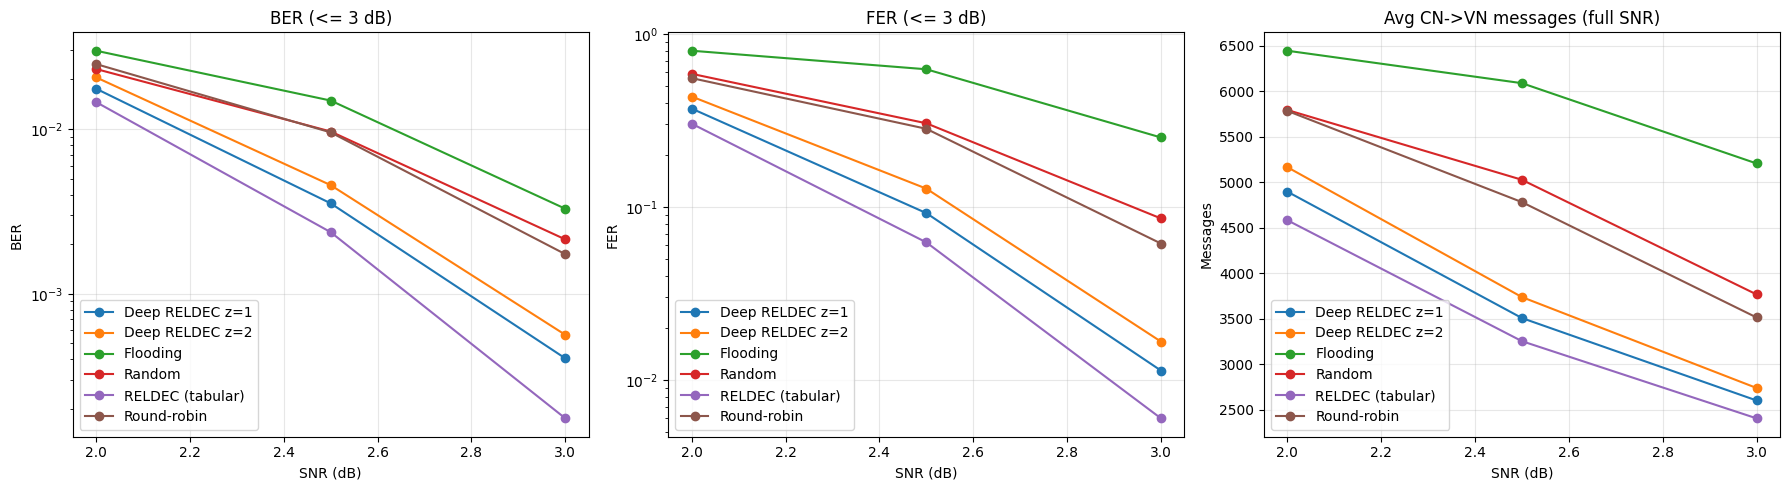

In [13]:
if not EVAL_CSV.exists():
    raise FileNotFoundError(f"Missing eval csv: {EVAL_CSV}")

df = pd.read_csv(EVAL_CSV)
df = df.sort_values(["method", "snr_db"]).reset_index(drop=True)

display(df)

# Clear method labels for legend readability.
label_map = {
    "deep_reldec_z1": "Deep RELDEC z=1",
    "deep_reldec_z2": "Deep RELDEC z=2",
    "reldec": "RELDEC (tabular)",
    "flooding": "Flooding",
    "random": "Random",
    "round_robin": "Round-robin",
}

# BER/FER limited to <= 3 dB. Avg messages keeps full range.
df_limited = df[df["snr_db"] <= 3.0].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for method, g in df.groupby("method"):
    pretty = label_map.get(method, method)
    g_limited = g[g["snr_db"] <= 3.0]

    if not g_limited.empty:
        axes[0].semilogy(g_limited["snr_db"], g_limited["ber"], marker="o", label=pretty)
        axes[1].semilogy(g_limited["snr_db"], g_limited["fer"], marker="o", label=pretty)

    axes[2].plot(g["snr_db"], g["avg_messages"], marker="o", label=pretty)

axes[0].set_title("BER (<= 3 dB)")
axes[1].set_title("FER (<= 3 dB)")
axes[2].set_title("Avg CN->VN messages (full SNR)")
for ax in axes:
    ax.set_xlabel("SNR (dB)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("BER")
axes[1].set_ylabel("FER")
axes[2].set_ylabel("Messages")

axes[0].legend(loc="best")
axes[1].legend(loc="best")
axes[2].legend(loc="best")

if "deep_reldec_z1" not in set(df["method"].astype(str)):
    print("Note: Deep RELDEC z=1 is not present in current eval results (no z1 checkpoint merged yet).")

plt.tight_layout()
plt.show()

## 8b) Persist Deep Artifacts + Curate Non-Deep (Archive, No Delete)

In [7]:
timestamp = time.strftime("%Y%m%d_%H%M%S")

def _copy_files(src_files, dst_dir: Path):
    dst_dir.mkdir(parents=True, exist_ok=True)
    copied = []
    for src in src_files:
        src = Path(src)
        if src.exists() and src.is_file():
            dst = dst_dir / src.name
            shutil.copy2(src, dst)
            copied.append(dst)
    return copied

def _copy_tree_files(src_dir: Path, dst_dir: Path):
    if not src_dir.exists() or not src_dir.is_dir():
        return []
    copied = []
    for item in src_dir.iterdir():
        if item.is_file():
            dst_dir.mkdir(parents=True, exist_ok=True)
            dst = dst_dir / item.name
            shutil.copy2(item, dst)
            copied.append(dst)
    return copied

deep_z2_ckpt_sources = [
    CKPT_DIR,
    WRAN_ROOT / "checkpoints_deep_z2_resume_live",
    WRAN_ROOT / "checkpoints_deep_z2_smoke",
]
deep_z1_ckpt_sources = [
    Z1_CKPT_DIR,
    WRAN_ROOT / "checkpoints_deep_z1_resume_live",
    WRAN_ROOT / "checkpoints_deep_z1_smoke",
]

deep_z2_results = [p for p in RESULTS_DIR.glob("*.csv") if "deep" in p.name and "z2" in p.name]
deep_z2_results += [p for p in RESULTS_DIR.glob("*.json") if "deep" in p.name and "z2" in p.name]
deep_z1_results = [p for p in RESULTS_DIR.glob("*.csv") if "deep" in p.name and "z1" in p.name]
deep_z1_results += [p for p in RESULTS_DIR.glob("*.json") if "deep" in p.name and "z1" in p.name]

# Include merged evaluation files that may contain both z1/z2 rows.
if EVAL_CSV.exists():
    deep_z2_results.append(EVAL_CSV)
if EVAL_JSON.exists():
    deep_z2_results.append(EVAL_JSON)

z2_copied = []
for src in deep_z2_ckpt_sources:
    z2_copied.extend(_copy_tree_files(src, DEEP_Z2_STORE / "wran" / "checkpoints" / src.name))
z2_copied.extend(_copy_files(deep_z2_results, DEEP_Z2_STORE / "wran" / "results"))

z1_copied = []
for src in deep_z1_ckpt_sources:
    z1_copied.extend(_copy_tree_files(src, DEEP_Z1_STORE / "wran" / "checkpoints" / src.name))
z1_copied.extend(_copy_files(deep_z1_results, DEEP_Z1_STORE / "wran" / "results"))

# Curate non-deep by keeping highest-frames row per (method, snr_db).
non_deep_methods = {"flooding", "random", "round_robin", "reldec"}
non_deep_csv_files = [
    p for p in RESULTS_DIR.glob("*.csv")
    if "deep" not in p.name.lower()
    and not p.name.lower().startswith("tmp_")
]

non_deep_rows = []
for csv_file in non_deep_csv_files:
    try:
        df_src = pd.read_csv(csv_file)
    except Exception:
        continue
    if "method" not in df_src.columns or "frames" not in df_src.columns or "snr_db" not in df_src.columns:
        continue
    part = df_src[df_src["method"].astype(str).str.lower().isin(non_deep_methods)].copy()
    if part.empty:
        continue
    part["_source_csv"] = str(csv_file)
    non_deep_rows.append(part)

curated_dir = CURATED_STORE / "wran" / "results"
curated_dir.mkdir(parents=True, exist_ok=True)
archive_dir = CURATED_STORE / "wran" / "archive" / f"non_deep_raw_{timestamp}"
archive_dir.mkdir(parents=True, exist_ok=True)

if non_deep_rows:
    non_deep_df = pd.concat(non_deep_rows, ignore_index=True)
    non_deep_df["method"] = non_deep_df["method"].astype(str).str.lower()
    non_deep_df["snr_db"] = non_deep_df["snr_db"].astype(float)
    non_deep_df["frames"] = non_deep_df["frames"].astype(int)

    idx = non_deep_df.groupby(["method", "snr_db"])["frames"].idxmax()
    curated_df = non_deep_df.loc[idx].sort_values(["method", "snr_db"]).reset_index(drop=True)

    curated_csv = curated_dir / "non_deep_highest_frames.csv"
    curated_json = curated_dir / "non_deep_highest_frames.json"
    curated_df.to_csv(curated_csv, index=False)
    curated_json.write_text(
        json.dumps(curated_df.to_dict(orient="records"), indent=2),
        encoding="utf-8",
    )

    archived_csv = _copy_files(non_deep_csv_files, archive_dir)
    archived_json = _copy_files([p.with_suffix(".json") for p in non_deep_csv_files], archive_dir)
else:
    curated_df = pd.DataFrame()
    curated_csv = curated_dir / "non_deep_highest_frames.csv"
    curated_json = curated_dir / "non_deep_highest_frames.json"
    archived_csv = []
    archived_json = []

z2_manifest = {
    "created_at": timestamp,
    "type": "deep_reldec_z2",
    "checkpoint_store": str(DEEP_Z2_STORE / "wran" / "checkpoints"),
    "results_store": str(DEEP_Z2_STORE / "wran" / "results"),
    "copied_files": [str(p) for p in z2_copied],
    "continuous_training_checkpoint": str(CKPT_DIR / "checkpoint_latest.npz"),
}
(DEEP_Z2_STORE / "manifest.json").write_text(json.dumps(z2_manifest, indent=2), encoding="utf-8")

z1_manifest = {
    "created_at": timestamp,
    "type": "deep_reldec_z1",
    "checkpoint_store": str(DEEP_Z1_STORE / "wran" / "checkpoints"),
    "results_store": str(DEEP_Z1_STORE / "wran" / "results"),
    "copied_files": [str(p) for p in z1_copied],
    "continuous_training_checkpoint": str(Z1_CKPT_DIR / "checkpoint_latest.npz"),
}
(DEEP_Z1_STORE / "manifest.json").write_text(json.dumps(z1_manifest, indent=2), encoding="utf-8")

curated_manifest = {
    "created_at": timestamp,
    "policy": "archive_non_deep_raw_keep_highest_frames",
    "curated_csv": str(curated_csv),
    "curated_json": str(curated_json),
    "curated_rows": int(len(curated_df)),
    "archived_csv_files": [str(p) for p in archived_csv],
    "archived_json_files": [str(p) for p in archived_json],
}
(CURATED_STORE / "wran" / "manifest.json").write_text(json.dumps(curated_manifest, indent=2), encoding="utf-8")

print(f"Deep z2 folder synced: {DEEP_Z2_STORE}")
print(f"Deep z1 folder synced: {DEEP_Z1_STORE}")
print(f"Curated non-deep data: {curated_csv}")
print(f"Archived non-deep raw data: {archive_dir}")
print(f"Counts -> z2 files: {len(z2_copied)}, z1 files: {len(z1_copied)}, curated rows: {len(curated_df)}")

Deep z2 folder synced: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/deep_reldec_z2
Deep z1 folder synced: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/deep_reldec_z1
Curated non-deep data: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/curated_non_deep/wran/results/non_deep_highest_frames.csv
Archived non-deep raw data: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/curated_non_deep/wran/archive/non_deep_raw_20260410_200452
Counts -> z2 files: 53, z1 files: 34, curated rows: 32


## 9) Validate the Resumed Model Checkpoint

In [8]:
# Quick validation summary against pre-interruption benchmark fields.
summary_path = CKPT_DIR / "training_summary.json"
if not summary_path.exists():
    raise FileNotFoundError(f"Missing training summary: {summary_path}")

summary = json.loads(summary_path.read_text(encoding="utf-8"))
progress = summary.get("progress", {})
print("Training summary:")
print(json.dumps(progress, indent=2))

if EVAL_JSON.exists():
    payload = json.loads(EVAL_JSON.read_text(encoding="utf-8"))
    rows = payload.get("results", [])
    deep_rows = [r for r in rows if r.get("method") == "deep_reldec_z2"]
    if deep_rows:
        best_fer = min(float(r["fer"]) for r in deep_rows)
        best_ber = min(float(r["ber"]) for r in deep_rows)
        print(f"Deep z2 best FER in this eval: {best_fer:.6e}")
        print(f"Deep z2 best BER in this eval: {best_ber:.6e}")
    else:
        print("No deep_reldec_z2 rows in eval JSON")
else:
    print("Run Section 8 first to validate metrics on resumed checkpoint")

Training summary:
{
  "episodes_completed": 120,
  "total_updates": 2400,
  "mean_reward": 0.9651685606060604,
  "elapsed_sec": 0.0
}
Deep z2 best FER in this eval: 1.666667e-02
Deep z2 best BER in this eval: 5.633681e-04
